In [2]:
# [LABEL: Setup] Mounting Drive and Installing Industrial-Grade NLP Tools
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers[torch] datasets evaluate rouge_score accelerate matplotlib

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [3]:
# [LABEL: Preprocessing] Loading Dataset and Cleaning News Metadata (CNN/DailyMail headers)
import re
from datasets import load_dataset

def clean_text(text):
    """Removes bylines like '(CNN) --' and 'Daily Mail' noise."""
    text = text.lower()
    text = re.sub(r'.*?\(cnn\)\s*--\s*', '', text) 
    text = re.sub(r'\(daily mail\)', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load 10% slice for efficient training on T4 GPU
raw_data = load_dataset("cnn_dailymail", "3.0.0", split="train[:10%]").shuffle(seed=42)
raw_data = raw_data.map(lambda x: {"article": clean_text(x["article"])})

# 90/10 Split for rigorous validation
split_data = raw_data.train_test_split(test_size=0.1)
train_set, val_set = split_data["train"], split_data["test"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Map:   0%|          | 0/28711 [00:00<?, ? examples/s]

In [4]:
# [LABEL: Tokenization] Transforming text into GPU-ready IDs and setting up ROUGE metrics
import evaluate
import numpy as np
from transformers import T5Tokenizer

tokenizer = T5Tokenizer.from_pretrained("t5-small")
rouge = evaluate.load("rouge")

def preprocess_function(examples):
    inputs = ["summarize: " + doc for doc in examples["article"]]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")
    labels = tokenizer(text_target=examples["highlights"], max_length=64, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v, 4) for k, v in result.items()}

tokenized_train = train_set.map(preprocess_function, batched=True)
tokenized_val = val_set.map(preprocess_function, batched=True)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25839 [00:00<?, ? examples/s]

Map:   0%|          | 0/2872 [00:00<?, ? examples/s]

In [5]:
# [LABEL: Training] Fine-tuning T5-Small with automatic checkpoints to Google Drive
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, T5ForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

model_path = "/content/drive/MyDrive/scribe_model_final"

training_args = Seq2SeqTrainingArguments(
    output_dir=model_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.143517,1.917669,0.233200,0.091200,0.189000,0.188900
2,2.102400,1.893139,0.234800,0.092400,0.190500,0.190400
3,2.085865,1.888905,0.234200,0.091500,0.190300,0.190200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9690, training_loss=2.1511361042412442, metrics={'train_runtime': 2295.7016, 'train_samples_per_second': 33.766, 'train_steps_per_second': 4.221, 'total_flos': 1.0491290424705024e+16, 'train_loss': 2.1511361042412442, 'epoch': 3.0})

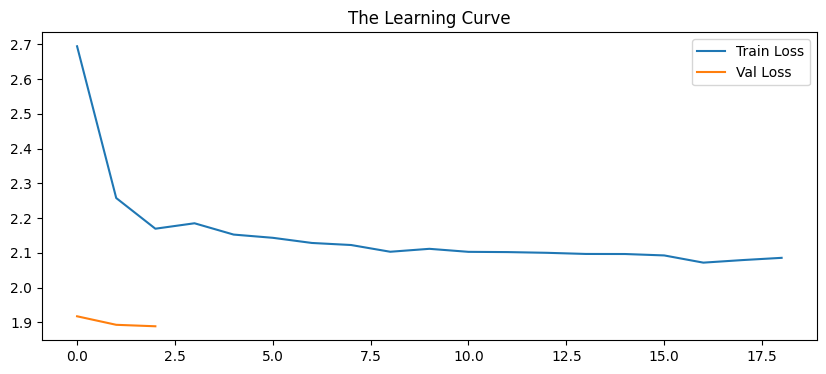

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model safely archived to: /content/drive/MyDrive/final_news_t5_model


In [6]:
# [LABEL: Evaluation] Visualizing Loss Curves and Saving Clean Weights
import matplotlib.pyplot as plt

# 1. Plot Learning Curve
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Val Loss")
plt.title("The Learning Curve")
plt.legend(); plt.show()

# 2. Save Final Clean Model
final_path = "/content/drive/MyDrive/final_news_t5_model"
trainer.save_model(final_path)
tokenizer.save_pretrained(final_path)
print(f"Model safely archived to: {final_path}")